In [7]:
import pickle
import numpy as np

In [8]:
with open('inference/SMARTBind/robin1M_vs_result.pkl', 'rb') as f:
    data = pickle.load(f)

In [9]:
def calculate_ef(rank_percentile_list, threshold):
    """
    Calculate Enrichment Factor
    rank_percentile_list: list of rank percentiles for active compounds
    threshold: threshold value (e.g., 1, 3, 5 for 1%, 3%, 5%)
    """
    # Total number of active compounds
    total_actives = len(rank_percentile_list)
    
    # Number of active compounds found in top threshold%
    actives_found = np.sum(np.array(rank_percentile_list) <= threshold)
    
    # Enrichment Factor = (actual found ratio) / (random selection ratio)
    ef = (actives_found / total_actives) / (threshold / 100)
    
    return ef

# Calculate EF values for all targets
ef_results = {}

for key in data.keys():
    rank_percentile_list = data[key]
    
    ef_0_05 = calculate_ef(rank_percentile_list, 0.05)
    ef_0_1 = calculate_ef(rank_percentile_list, 0.1)
    ef_0_5 = calculate_ef(rank_percentile_list, 0.5)
    ef_1 = calculate_ef(rank_percentile_list, 1)
    ef_3 = calculate_ef(rank_percentile_list, 3)
    ef_5 = calculate_ef(rank_percentile_list, 5)
    ef_10 = calculate_ef(rank_percentile_list, 10)
    
    ef_results[key] = {
        'EF@0.05%': ef_0_05,
        'EF@0.1%': ef_0_1,
        'EF@0.5%': ef_0_5,
        'EF@1%': ef_1,
        'EF@3%': ef_3,
        'EF@5%': ef_5,
        'EF@10%': ef_10,
        'n_actives': len(rank_percentile_list)
    }

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## Analysis by RNA Structure Type

In [11]:
# Categorize targets by RNA structure type
structure_types = {
    'Hairpin': [],
    'Three-way_junction': [],
    'Pseudoknot': [],
    'G-quadruplex': [],
    'Triple_helix': []
}

# Classify each target based on keywords in their names
for target in data.keys():
    if 'Hairpin' in target:
        structure_types['Hairpin'].append(target)
    elif 'Three-way_junction' in target:
        structure_types['Three-way_junction'].append(target)
    elif 'Pseudoknot' in target:
        structure_types['Pseudoknot'].append(target)
    elif 'G-quadruplex' in target:
        structure_types['G-quadruplex'].append(target)
    elif 'Triple_helix' in target:
        structure_types['Triple_helix'].append(target)

# Print classification results
print("RNA Structure Type Classification:")
print("="*60)
for struct_type, targets in structure_types.items():
    print(f"\n{struct_type} ({len(targets)} targets):")
    for target in targets:
        print(f"  - {target}")

RNA Structure Type Classification:

Hairpin (14 targets):
  - BCL_XL_Hairpin
  - KLF6_wt_Hairpin
  - BCL_XL_SS_Hairpin
  - RRE2B_Hairpin
  - KLF6_mut_Hairpin
  - HIV_SL3_Hairpin
  - FGFR_Hairpin
  - Pro_wt_Hairpin
  - Pro_mut_Hairpin
  - Pre_miR_17_Hairpin
  - Pre_miR_21_Hairpin
  - Pre_miR_31_Hairpin
  - HBV_Hairpin
  - RRE2B_MeA_Hairpin

Three-way_junction (2 targets):
  - Glutamine_RS_Three-way_junction
  - TPP_Three-way_junction

Pseudoknot (3 targets):
  - PreQ1_Pseudoknot
  - SAM_ll_Pseudoknot
  - ZTP_Pseudoknot

G-quadruplex (6 targets):
  - Zika_NS5_G-quadruplex
  - EWSR1_G-quadruplex
  - TERRA_G-quadruplex
  - NRAS_G-quadruplex
  - AKTIP_G-quadruplex
  - Zika3PrimeUTR_G-quadruplex

Triple_helix (2 targets):
  - ENE_A9_Triple_helix
  - MALAT1_Triple_helix


In [12]:
# Calculate average EF values for each structure type
structure_ef_results = {}

for struct_type, targets in structure_types.items():
    if len(targets) > 0:
        # Collect EF values for all targets in this structure type
        struct_efs = {
            'EF@0.05%': [],
            'EF@0.1%': [],
            'EF@0.5%': [],
            'EF@1%': [],
            'EF@3%': [],
            'EF@5%': [],
            'EF@10%': []
        }
        
        for target in targets:
            for ef_key in struct_efs.keys():
                struct_efs[ef_key].append(ef_results[target][ef_key])
        
        # Calculate averages
        structure_ef_results[struct_type] = {
            ef_key: np.mean(values) for ef_key, values in struct_efs.items()
        }
        structure_ef_results[struct_type]['n_targets'] = len(targets)

# Print results
print("\nAverage EF Values by RNA Structure Type:")
print("="*80)
for struct_type, ef_vals in structure_ef_results.items():
    print(f"\n{struct_type} (n={ef_vals['n_targets']}):")
    print(f"  EF@0.05%:  {ef_vals['EF@0.05%']:.2f}")
    print(f"  EF@0.1%:   {ef_vals['EF@0.1%']:.2f}")
    print(f"  EF@0.5%:   {ef_vals['EF@0.5%']:.2f}")
    print(f"  EF@1%:     {ef_vals['EF@1%']:.2f}")
    print(f"  EF@3%:     {ef_vals['EF@3%']:.2f}")
    print(f"  EF@5%:     {ef_vals['EF@5%']:.2f}")
    print(f"  EF@10%:    {ef_vals['EF@10%']:.2f}")


Average EF Values by RNA Structure Type:

Hairpin (n=14):
  EF@0.05%:  1.42
  EF@0.1%:   3.68
  EF@0.5%:   2.44
  EF@1%:     2.18
  EF@3%:     1.91
  EF@5%:     1.72
  EF@10%:    1.41

Three-way_junction (n=2):
  EF@0.05%:  14.29
  EF@0.1%:   7.14
  EF@0.5%:   2.04
  EF@1%:     1.74
  EF@3%:     1.46
  EF@5%:     1.53
  EF@10%:    1.73

Pseudoknot (n=3):
  EF@0.05%:  3.99
  EF@0.1%:   3.95
  EF@0.5%:   1.91
  EF@1%:     1.52
  EF@3%:     1.58
  EF@5%:     1.65
  EF@10%:    1.59

G-quadruplex (n=6):
  EF@0.05%:  11.69
  EF@0.1%:   8.94
  EF@0.5%:   3.56
  EF@1%:     2.56
  EF@3%:     1.95
  EF@5%:     1.72
  EF@10%:    1.60

Triple_helix (n=2):
  EF@0.05%:  0.00
  EF@0.1%:   0.00
  EF@0.5%:   3.07
  EF@1%:     3.04
  EF@3%:     2.62
  EF@5%:     2.53
  EF@10%:    1.77


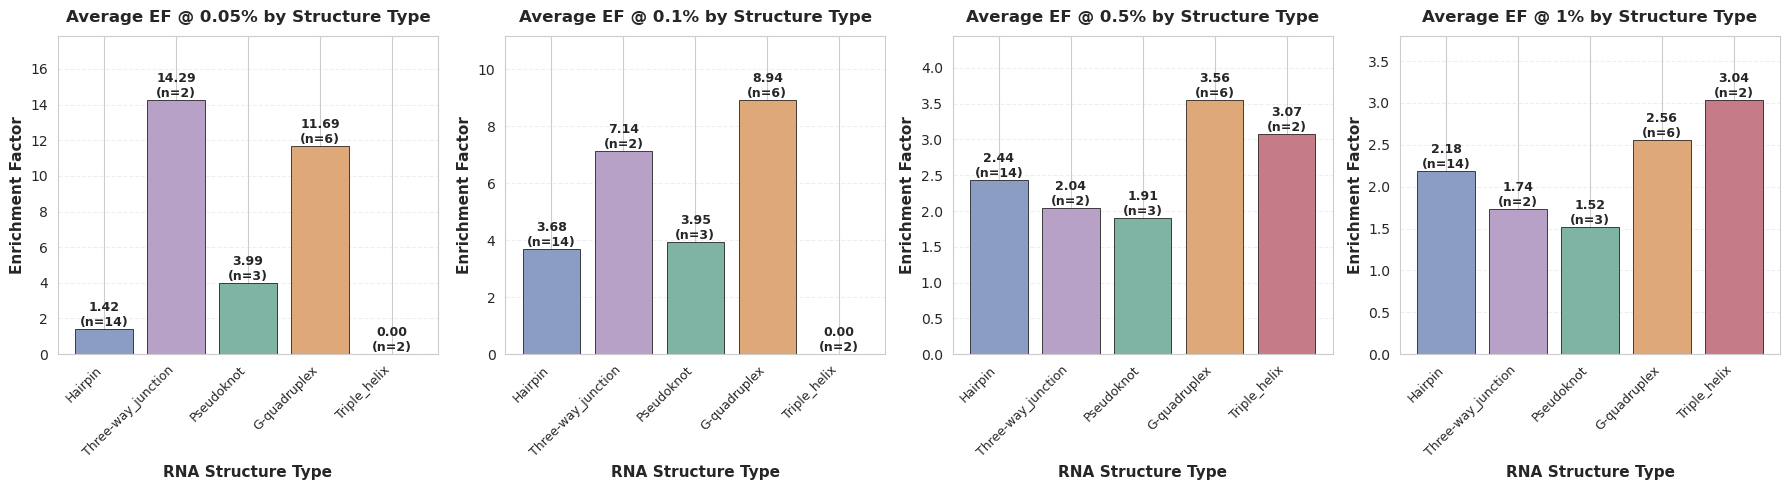

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

motif_colors = {
    'Hairpin': '#8B9DC3',           
    'G-quadruplex': '#DFA878',     
    'Pseudoknot': '#7FB3A4',       
    'Triple_helix': '#C67B88',      
    'Three-way_junction': '#B8A1C7'
}

# Define thresholds to plot
plot_thresholds = [
    ('EF@0.05%', '0.05%'),
    ('EF@0.1%', '0.1%'),
    ('EF@0.5%', '0.5%'),
    ('EF@1%', '1%')
]

structure_names = list(structure_ef_results.keys())

for idx, (ef_key, threshold_label) in enumerate(plot_thresholds):
    ax = axes[idx]
    
    # Get EF values for each structure type
    ef_values = [structure_ef_results[struct][ef_key] for struct in structure_names]
    n_targets = [structure_ef_results[struct]['n_targets'] for struct in structure_names]
    
    # Map structure names to colors
    colors = [motif_colors[struct] for struct in structure_names]
    
    # Create bars
    bars = ax.bar(range(len(structure_names)), ef_values, 
                   color=colors, edgecolor='black', linewidth=0.5)
    
    # Add value labels on bars
    for i, (bar, n) in enumerate(zip(bars, n_targets)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}\n(n={n})',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('RNA Structure Type', fontsize=11, fontweight='bold')
    ax.set_ylabel('Enrichment Factor', fontsize=11, fontweight='bold')
    ax.set_title(f'Average EF @ {threshold_label} by Structure Type', 
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(range(len(structure_names)))
    ax.set_xticklabels(structure_names, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(0, max(ef_values) * 1.25)

plt.tight_layout()
plt.show()

In [14]:
# Combined Enrichment Curves: SMARTBind vs RNAsmol
import pickle, os, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)
np.random.seed(42)

motif_colors = {
    'Hairpin': '#8B9DC3',
    'G-quadruplex': '#DFA878',
    'Pseudoknot': '#7FB3A4',
    'Triple_helix': '#C67B88',
    'Three-way_junction': '#B8A1C7'
}

def classify_motif(name):
    if 'Hairpin' in name:
        return 'Hairpin'
    elif 'Three-way_junction' in name or 'Three_way_junction' in name:
        return 'Three-way_junction'
    elif 'Pseudoknot' in name:
        return 'Pseudoknot'
    elif 'G-quadruplex' in name or 'G_quadruplex' in name:
        return 'G-quadruplex'
    elif 'Triple_helix' in name:
        return 'Triple_helix'
    return 'Other'

x_grid = np.linspace(0, 100, 2000)

# SMARTBind enrichment curves (from rank percentile data)
with open('inference/SMARTBind/robin1M_vs_result.pkl', 'rb') as f:
    smartbind_data = pickle.load(f)

smartbind_curves = {}
for target, rank_percentiles in smartbind_data.items():
    motif = classify_motif(target)
    if motif == 'Other':
        continue
    rank_arr = np.array(rank_percentiles)
    total_actives = len(rank_arr)
    fractions_found = np.array([np.sum(rank_arr <= x) / total_actives * 100 for x in x_grid])
    if motif not in smartbind_curves:
        smartbind_curves[motif] = []
    smartbind_curves[motif].append(fractions_found)

Total SMARTBind targets: 27
Total RNAsmol targets: 26


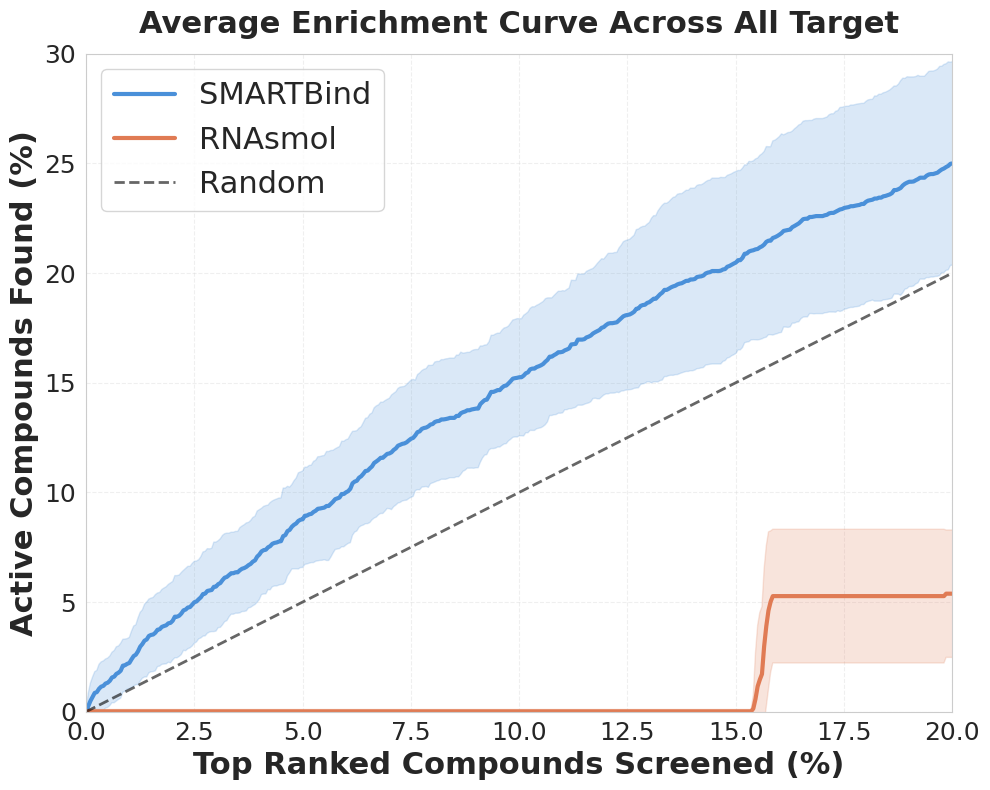

In [15]:
rnasmol_base = '/blue/yanjun.li/sjiang43.johnshopkins/pub_version/v3_1119/SMARTBind-internal/revision/baseline_models/binding_score/RNAsmol/robin_out'
robin_path = '/blue/yanjun.li/sjiang43.johnshopkins/pub_version/v3_1119/SMARTBind-internal/revision/data/robin/robin_processed'
rnasmol_model = 'pdb_bothaug_molperturbation'
rnasmol_model_dir = os.path.join(rnasmol_base, rnasmol_model)

# Build num_dict
num_dict = {}
for f in os.listdir(robin_path):
    csv_path = os.path.join(robin_path, f, 'raw/data_set.csv')
    if os.path.exists(csv_path):
        true_pd = pd.read_csv(csv_path)
        num_dict[f + '_test_pred'] = len(true_pd)

rnasmol_curves = {}
for f in os.listdir(rnasmol_model_dir):
    if f.endswith('.npy'):
        pocket_name = f.replace('_test_pred.npy', '_test_pred')
        if pocket_name not in num_dict:
            continue
        num_actives = num_dict[pocket_name]
        scores = np.load(os.path.join(rnasmol_model_dir, f))
        labels = np.array([1] * num_actives + [0] * (len(scores) - num_actives))
        
        # Sort by score descending
        sorted_indices = np.argsort(-scores)
        sorted_labels = labels[sorted_indices]
        cumulative_actives = np.cumsum(sorted_labels)
        fractions_found = cumulative_actives / num_actives  # 0-1
        fractions_screened = np.arange(1, len(scores) + 1) / len(scores)  # 0-1
        
        # Interpolate to common x_grid (in %)
        interp_ff = np.interp(x_grid / 100, fractions_screened, fractions_found) * 100
        
        motif = classify_motif(pocket_name)
        if motif == 'Other':
            continue
        if motif not in rnasmol_curves:
            rnasmol_curves[motif] = []
        rnasmol_curves[motif].append(interp_ff)

# Combine all SMARTBind curves across all motifs
all_smartbind_curves = []
for motif, curves in smartbind_curves.items():
    all_smartbind_curves.extend(curves)
all_smartbind_curves = np.array(all_smartbind_curves)

# Combine all RNAsmol curves across all motifs
all_rnasmol_curves = []
for motif, curves in rnasmol_curves.items():
    all_rnasmol_curves.extend(curves)
all_rnasmol_curves = np.array(all_rnasmol_curves)

# Calculate overall averages and std
smartbind_avg = np.mean(all_smartbind_curves, axis=0)
smartbind_std = np.std(all_smartbind_curves, axis=0)
rnasmol_avg = np.mean(all_rnasmol_curves, axis=0)
rnasmol_std = np.std(all_rnasmol_curves, axis=0)

print(f"Total SMARTBind targets: {len(all_smartbind_curves)}")
print(f"Total RNAsmol targets: {len(all_rnasmol_curves)}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# SMARTBind
ax.plot(x_grid, smartbind_avg, color='#4A90D9', linewidth=3, 
        label='SMARTBind')
ax.fill_between(x_grid, smartbind_avg - smartbind_std, smartbind_avg + smartbind_std,
                color='#4A90D9', alpha=0.2)

# RNAsmol
ax.plot(x_grid, rnasmol_avg, color='#E07B54', linewidth=3, 
        label='RNAsmol')
ax.fill_between(x_grid, rnasmol_avg - rnasmol_std, rnasmol_avg + rnasmol_std,
                color='#E07B54', alpha=0.2)

# Random baseline
ax.plot([0, 20], [0, 20], 'k--', linewidth=2, alpha=0.6, label='Random')

ax.set_xlim(0, 20)
ax.set_ylim(0, 30)
ax.set_xlabel('Top Ranked Compounds Screened (%)', fontsize=22, fontweight='bold')
ax.set_ylabel('Active Compounds Found (%)', fontsize=22, fontweight='bold')
ax.set_title('Average Enrichment Curve Across All Target', 
             fontsize=22, fontweight='bold', pad=15)
ax.legend(fontsize=22, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', labelsize=18)

plt.tight_layout()
plt.show()